In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
def spatial_cross_covariance(da: xr.DataArray, mask: xr.DataArray, 
                             dim: str = "channels", norm: bool = False):
    """
    Calculates the spatial cross-covariance or cross-correlation matrix for all pairs 
    along dim.

    Args:
        da (xr.DataArray): The input DataArray, which should be loaded into memory.
                           ("sample", "lat", "lon", "channels").
        mask (xr.DataArray): Mask DataArray ("lat", "lon", "channels")
        dim (str): The dimension along which variables are defined (e.g., "channels").
        norm (bool): If true, compute correlation instead of covariance.

    Returns:
        xr.DataArray: A DataArray containing the full covariance or correlation matrix.
    """
    
    n_samples = da.sizes["sample"]
    n_channels = da.sizes["channels"]

    cov_mat = xr.DataArray(np.zeros((n_channels, n_channels)))
        
    for j in range(n_samples):
        print("j=", j)
        data = da.isel(sample=j)
        data = data*mask
        
        if not norm:
            statistic = "covariance"
            data_mean = data.sum(dim=("lat","lon"))/mask.sum(dim=("lat","lon"))
            data_demeaned = data - data_mean
            da1 = data_demeaned.rename({dim: f"{dim}_x"}).stack(latlon=("lat","lon"))
            da2 = data_demeaned.rename({dim: f"{dim}_y"}).stack(latlon=("lat","lon"))
            cov_map = xr.dot(da1, da2, dims="latlon") / (mask.sum(dim=("lat","lon"))-1)
            out_matrix = cov_map

        else:
            statistic = "correlation"
            # We first z-score the data and then compute the covariance of the result.
        
            # Calculate mean and sample standard deviation (with ddof=1).
            data_mean = data.sum(dim=("lat","lon"))/mask.sum(dim=("lat","lon"))
            data_squared = (data-data_mean)**2
            data_std = np.sqrt(data_squared.sum(dim=("lat","lon"))/(mask.sum(dim=("lat","lon"))-1))

            # Z-score the data.
            da_zscored = (data - data_mean) / data_std

            # divide by the sum of the mask beforehand to avoid creating a new "channels" dimension 
            da_zscored = da_zscored / np.sqrt(mask.sum(dim=("lat","lon"))-1)

            # The correlation is the covariance of the z-scored data.
            da1 = da_zscored.rename({dim: f"{dim}_x"}).stack(latlon=("lat","lon"))
            da2 = da_zscored.rename({dim: f"{dim}_y"}).stack(latlon=("lat","lon"))
            
            # The dot product of z-scored data, divided by (n-1), is the correlation map.
            corr_map = xr.dot(da1, da2, dims="latlon")
        
            out_matrix = corr_map

        # add to the overall sum for all ics thus far
        cov_mat = cov_mat + out_matrix

    cov_mat = cov_mat / n_samples
    cov_mat.attrs = {"description": f"tendency {statistic}"}
    
    return out_matrix

In [3]:
def load_training_data(config, varname="inputs"):
    """Loads reference truth data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], "training")
    fname = f"{location}/{varname}.zarr"
    training_data = xr.open_zarr(fname)
    
    return training_data

In [4]:
FIG_DIR = os.path.join(os.getcwd(), "figures")
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"

# Define a model config to pull the training data from
CONFIG = [
    {
        "name": "Emulator-24h-MSE",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay", 
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-mse"
    },
]

In [5]:
#### Main computation block ####
all_spatial_corr_mat = {}
forecast_days = 10
varname = "targets"

# Loop over models
for model_config in CONFIG:
    model_name = model_config["name"]
    print(f"\nPulling training data for the model: {model_name}")

    # Load and stack model prediction data once
    print("Loading the data...")
    ds = load_training_data(model_config, varname)
    print("Data loading completed successfully!!!")
    
    # get the mask
    print("Starting mask computation...")
    mask = xr.where(ds[varname].isel(sample=0)==0, 0, 1)
    print("mask diagnosed!!!")

    
    # compute correlation
    print("Computing correlations...")
    model_name = model_config["name"]
    all_spatial_corr_mat[model_name] = spatial_cross_covariance(ds[varname].isel(sample=slice(-300, None)), mask, dim="channels", norm=True).load()
    print("Correlation computed!!!")

print("\n --- All correlations computed!!! ---")


Pulling training data for the model: Emulator-24h-MSE
Loading the data...
Data loading completed successfully!!!
Starting mask computation...
mask diagnosed!!!
Computing correlations...
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 9
j= 10
j= 11
j= 12
j= 13
j= 14
j= 15
j= 16
j= 17
j= 18
j= 19
j= 20
j= 21
j= 22
j= 23
j= 24
j= 25
j= 26
j= 27
j= 28
j= 29
j= 30
j= 31
j= 32
j= 33
j= 34
j= 35
j= 36
j= 37
j= 38
j= 39
j= 40
j= 41
j= 42
j= 43
j= 44
j= 45
j= 46
j= 47
j= 48
j= 49
j= 50
j= 51
j= 52
j= 53
j= 54
j= 55
j= 56
j= 57
j= 58
j= 59
j= 60
j= 61
j= 62
j= 63
j= 64
j= 65
j= 66
j= 67
j= 68
j= 69
j= 70
j= 71
j= 72
j= 73
j= 74
j= 75
j= 76
j= 77
j= 78
j= 79
j= 80
j= 81
j= 82
j= 83
j= 84
j= 85
j= 86
j= 87
j= 88
j= 89
j= 90
j= 91
j= 92
j= 93
j= 94
j= 95
j= 96
j= 97
j= 98
j= 99
j= 100
j= 101
j= 102
j= 103
j= 104
j= 105
j= 106
j= 107
j= 108
j= 109
j= 110
j= 111
j= 112
j= 113
j= 114
j= 115
j= 116
j= 117
j= 118
j= 119
j= 120
j= 121
j= 122
j= 123
j= 124
j= 125
j= 126
j= 127
j= 128
j= 129
j= 130
j= 131

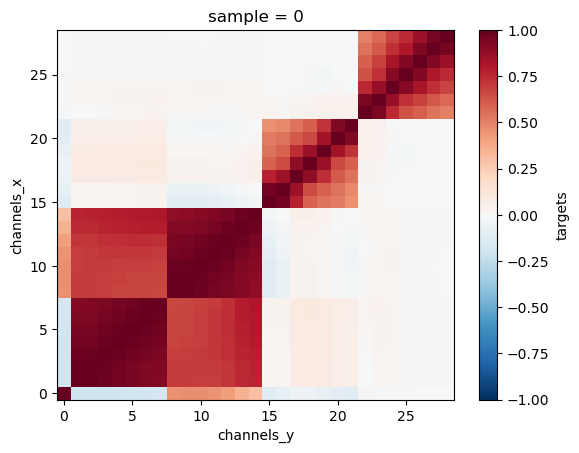

In [6]:
all_spatial_corr_mat["Emulator-24h-MSE"].plot()
plt.show()

In [9]:
## Save the result
output_file = f"./spatial_correlation_ocn_only_{model_config['timestep']}_{model_config['run']}_{model_config['expt']}.nc"
all_spatial_corr_mat["Emulator-24h-MSE"].to_netcdf(output_file)
print(f"Saved the matrix to {output_file}")

Saved the matrix to ./spatial_correlation_ocn_only_24h_R5_T1M.nc
